# 02 — Exploratory Analysis

Three questions drive this notebook:
1. Which occupations are most automated today, and is that changing?
2. Is the frontier between automation and augmentation "jagged" — unpredictable from simple proxies like wage?
3. What does mean reversion look like, and why does it matter for prediction?

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import build_occupation_panel, RELEASE_ORDER
from src.features import build_feature_matrix

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 150
C = {"auto": "#E63946", "aug": "#457B9D", "accent": "#F4A261", "neutral": "#264653"}

In [2]:
panel = build_occupation_panel()
features = build_feature_matrix()  # quality-filtered
print(f"Panel: {panel['soc_code'].nunique()} occupations (raw)")
print(f"Analysis set: {len(features)} occupations (quality-filtered)")

Panel: 633 occupations (raw)
Analysis set: 319 occupations (quality-filtered)


## The most automated occupations (with reliable data)

Filtered to occupations with >=200 conversations, >=3 tasks, >=3 releases.

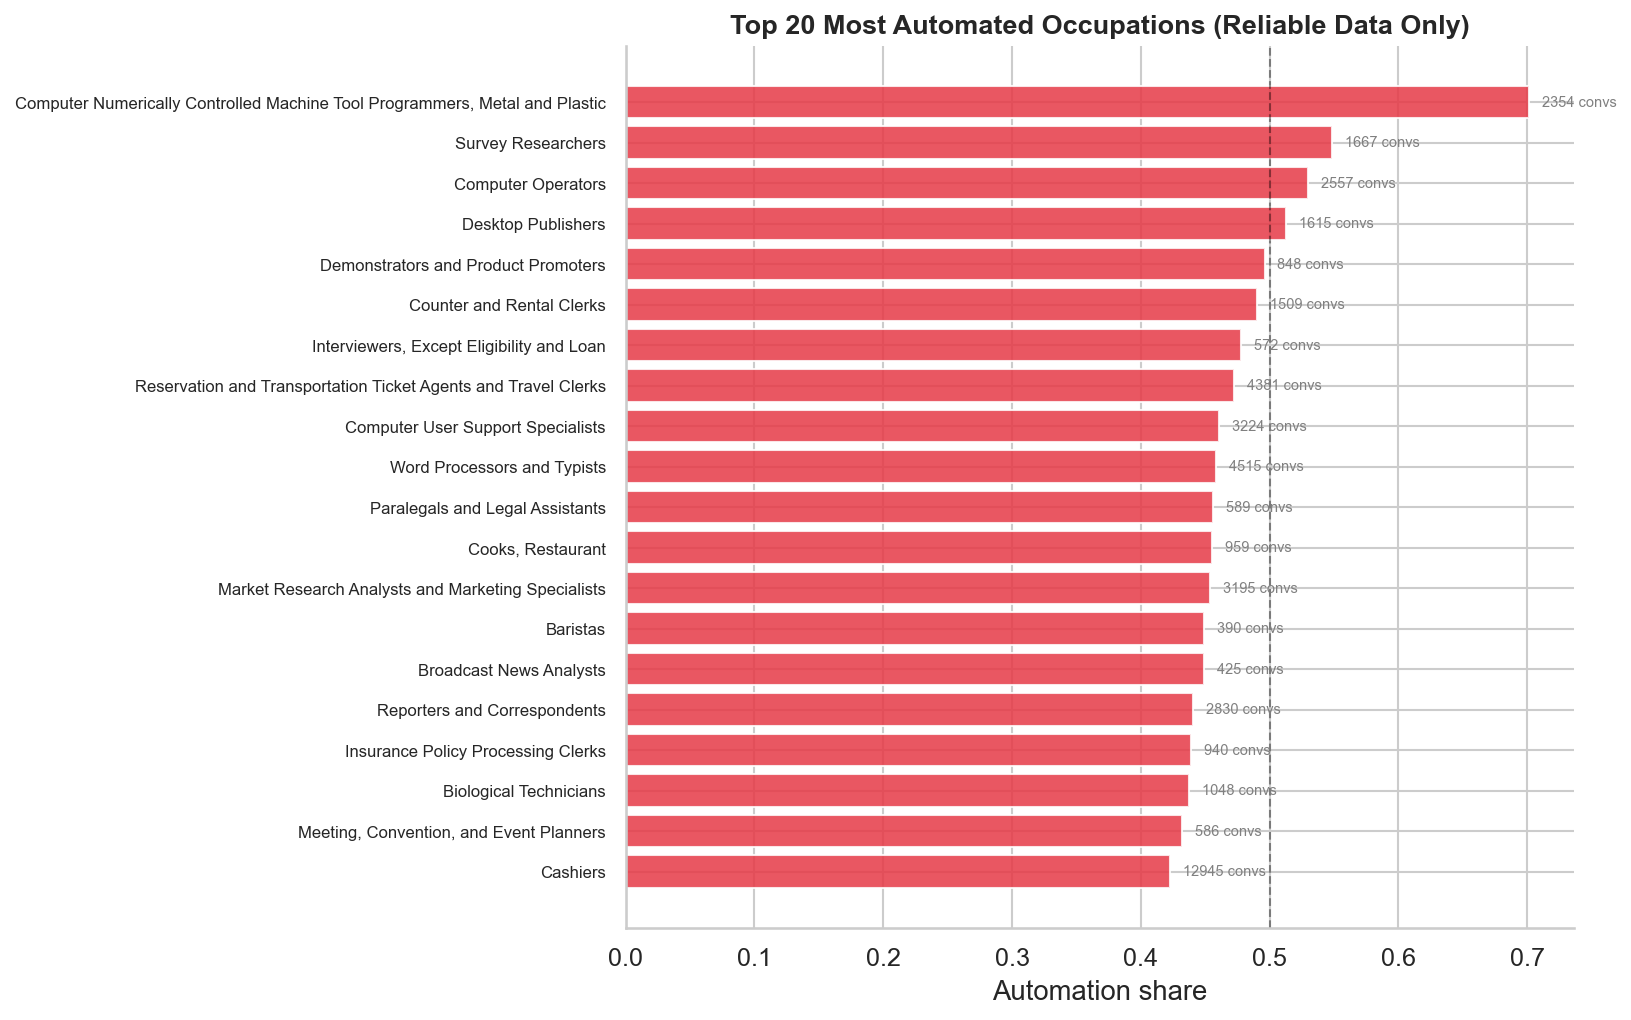


4 of 319 occupations are automation-dominant (>50%)


In [3]:
top = features.nlargest(20, 'latest_automation_share')

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(range(len(top)), top['latest_automation_share'],
               color=C['auto'], alpha=0.85, edgecolor='white')
# Add conversation count as text
for i, (_, row) in enumerate(top.iterrows()):
    ax.text(row['latest_automation_share'] + 0.01, i,
            f"{row['conversation_count']:.0f} convs",
            va='center', fontsize=7, color='gray')

ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['title'].values, fontsize=8)
ax.set_xlabel('Automation share')
ax.set_title('Top 20 Most Automated Occupations (Reliable Data Only)',
             fontsize=13, fontweight='bold')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.4)
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.savefig('../figures/03_top_automated_occupations.png', bbox_inches='tight')
plt.show()

n_above_50 = (features['latest_automation_share'] >= 0.5).sum()
print(f"\n{n_above_50} of {len(features)} occupations are automation-dominant (>50%)")

## Mean reversion: the dominant pattern

The single strongest signal in the data: **occupations that start with high
automation shares tend to decelerate, while those starting low tend to accelerate.**

This has a critical implication: naive models that predict "high automation → more
automation" will be wrong. The data shows convergence toward the mean, not divergence.

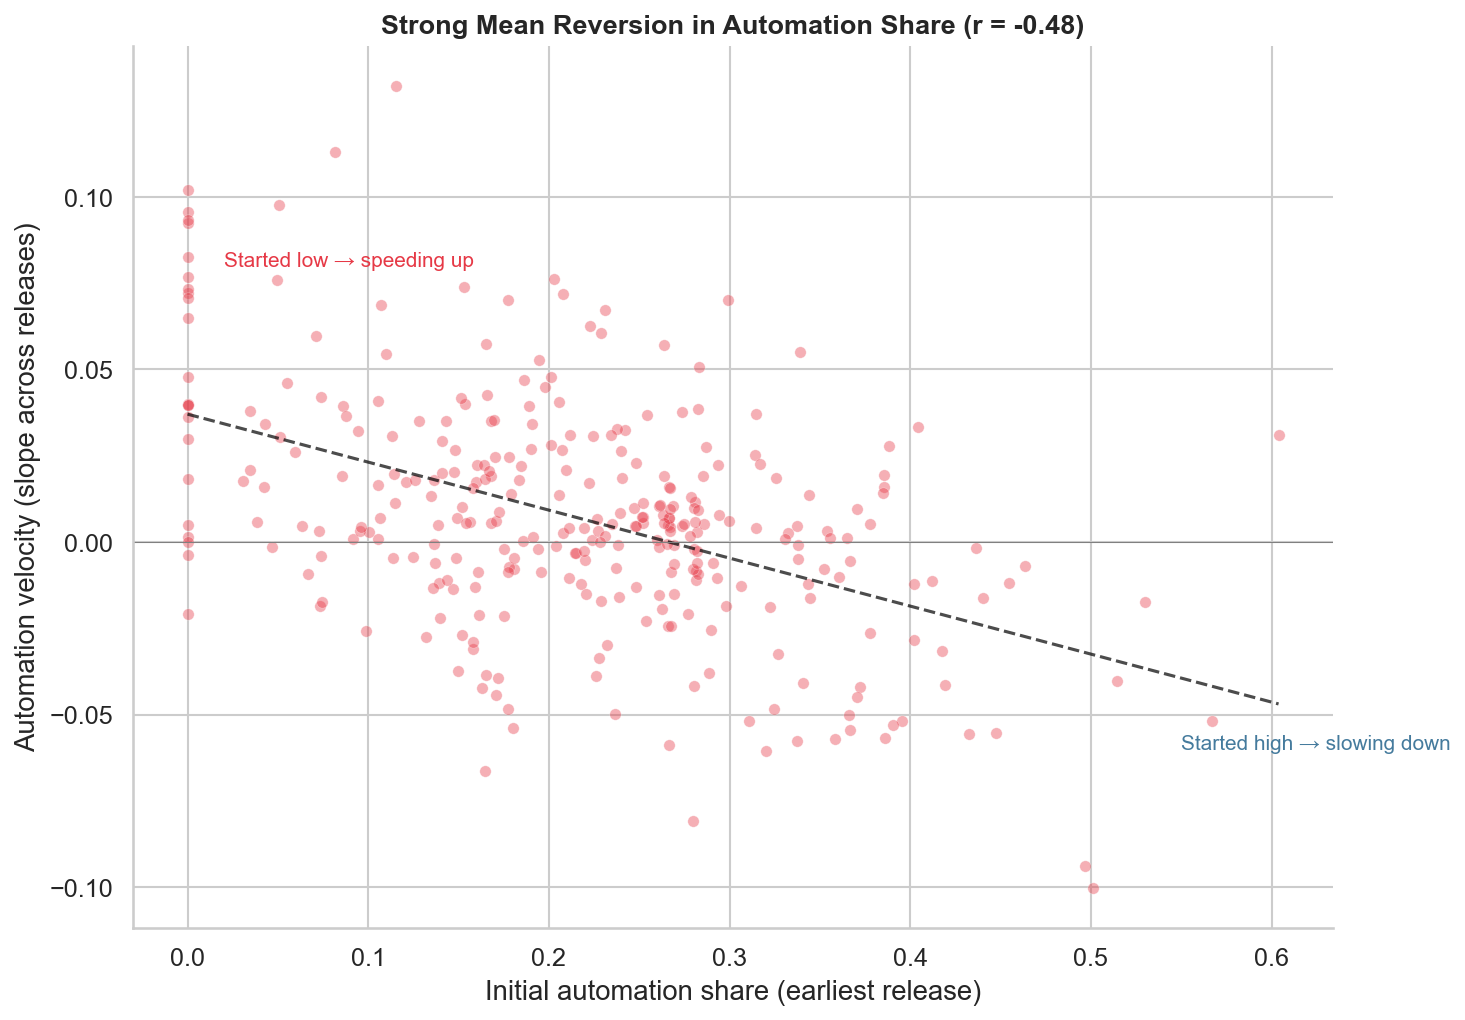

In [4]:
vel_df = features.dropna(subset=['automation_velocity']).copy()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(vel_df['initial_automation_share'], vel_df['automation_velocity'],
           alpha=0.4, s=30, color=C['auto'], edgecolors='white', linewidth=0.3)

# Trend line
z = np.polyfit(vel_df['initial_automation_share'], vel_df['automation_velocity'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, vel_df['initial_automation_share'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='black', linewidth=1.5, alpha=0.7)

ax.axhline(0, color='gray', linewidth=0.5)
corr = vel_df['initial_automation_share'].corr(vel_df['automation_velocity'])
ax.set_xlabel('Initial automation share (earliest release)')
ax.set_ylabel('Automation velocity (slope across releases)')
ax.set_title(f'Strong Mean Reversion in Automation Share (r = {corr:.2f})',
             fontsize=13, fontweight='bold')
ax.annotate('Started high → slowing down', xy=(0.55, -0.06), fontsize=10, color=C['aug'])
ax.annotate('Started low → speeding up', xy=(0.02, 0.08), fontsize=10, color=C['auto'])
sns.despine()
plt.tight_layout()
plt.savefig('../figures/04_mean_reversion.png', bbox_inches='tight')
plt.show()

## The Jagged Adoption Frontier

If automation followed simple rules ("low-wage jobs get automated first"),
we'd see a smooth relationship between wage and automation share.
Instead, we see a **jagged frontier** — wage explains very little.

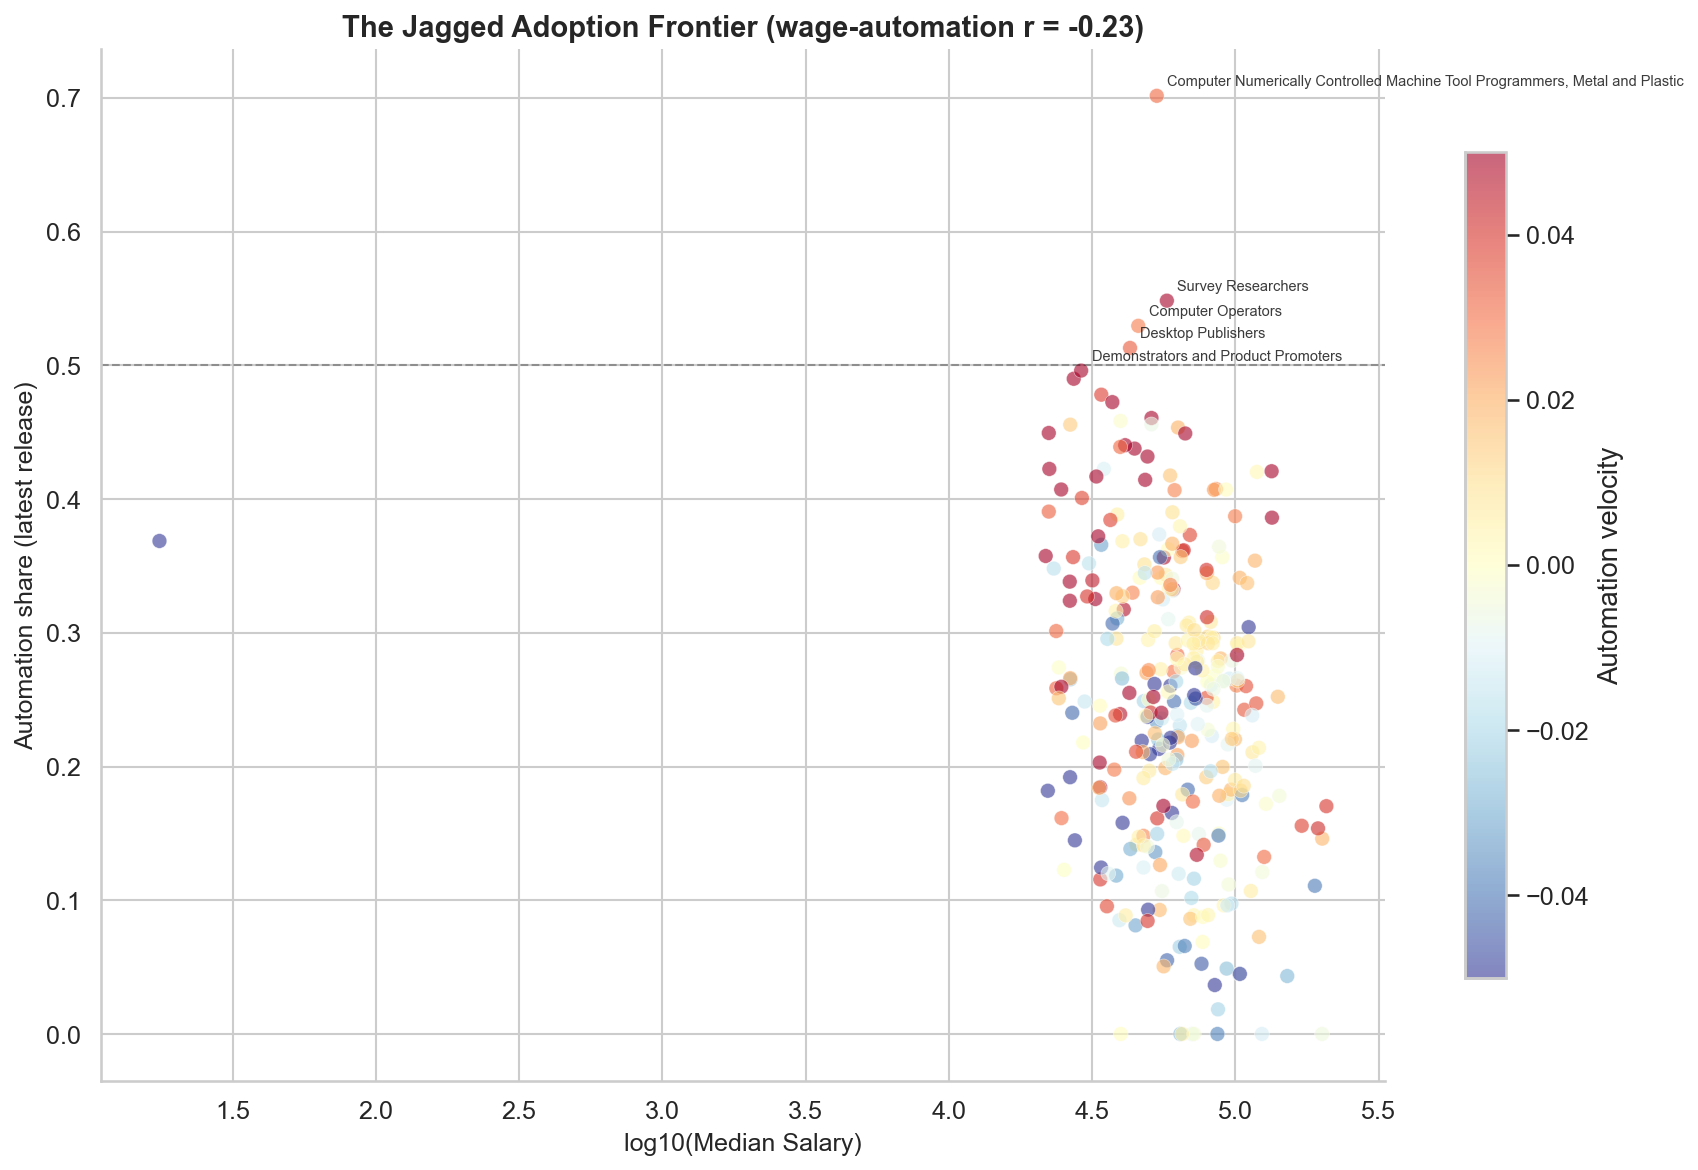

Wage explains only 5% of the variance in automation share.
The frontier is genuinely jagged — simple economic proxies don't predict automation.


In [5]:
plot_df = features.dropna(subset=['mediansalary', 'latest_automation_share']).copy()
plot_df['log_salary'] = np.log10(plot_df['mediansalary'].clip(lower=1))

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    plot_df['log_salary'], plot_df['latest_automation_share'],
    c=plot_df['automation_velocity'].fillna(0),
    cmap='RdYlBu_r', s=50, alpha=0.6, edgecolors='white', linewidth=0.3,
    vmin=-0.05, vmax=0.05,
)
plt.colorbar(scatter, ax=ax, label='Automation velocity', shrink=0.8)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.3)

# Annotate a few interesting occupations
highlights = plot_df.nlargest(5, 'latest_automation_share')
for _, row in highlights.iterrows():
    ax.annotate(row['title'], (row['log_salary'], row['latest_automation_share']),
                fontsize=7, alpha=0.9, xytext=(5, 5), textcoords='offset points')

corr = plot_df['log_salary'].corr(plot_df['latest_automation_share'])
ax.set_xlabel('log10(Median Salary)', fontsize=12)
ax.set_ylabel('Automation share (latest release)', fontsize=12)
ax.set_title(f'The Jagged Adoption Frontier (wage-automation r = {corr:.2f})',
             fontsize=14, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('../figures/05_jagged_adoption_frontier.png', bbox_inches='tight')
plt.show()

print(f"Wage explains only {corr**2:.0%} of the variance in automation share.")
print("The frontier is genuinely jagged — simple economic proxies don't predict automation.")

## Automation by occupation group

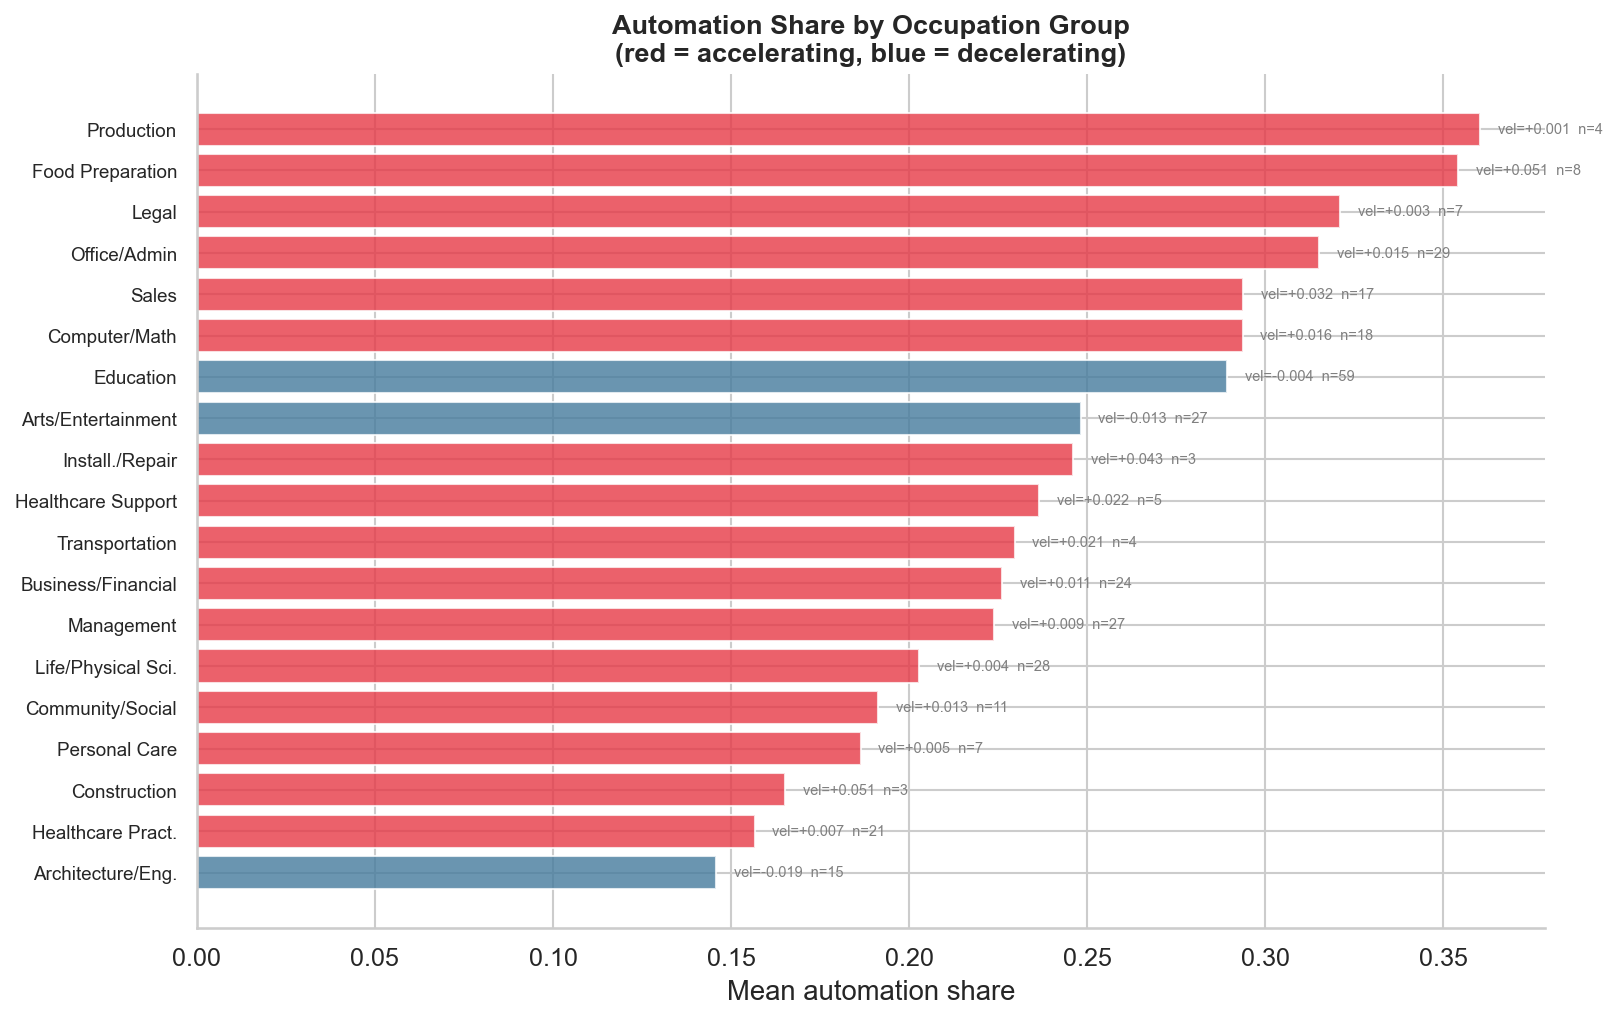

In [6]:
major_group_names = {
    '11': 'Management', '13': 'Business/Financial', '15': 'Computer/Math',
    '17': 'Architecture/Eng.', '19': 'Life/Physical Sci.',
    '21': 'Community/Social', '23': 'Legal', '25': 'Education',
    '27': 'Arts/Entertainment', '29': 'Healthcare Pract.',
    '31': 'Healthcare Support', '33': 'Protective Service',
    '35': 'Food Preparation', '37': 'Building/Grounds',
    '39': 'Personal Care', '41': 'Sales', '43': 'Office/Admin',
    '45': 'Farming/Fishing', '47': 'Construction', '49': 'Install./Repair',
    '51': 'Production', '53': 'Transportation',
}

features['group_name'] = features['major_group'].map(major_group_names)
group_stats = (
    features.groupby('group_name')
    .agg(
        mean_auto=('latest_automation_share', 'mean'),
        mean_vel=('automation_velocity', 'mean'),
        n=('soc_code', 'count'),
        mean_convs=('conversation_count', 'mean'),
    )
    .dropna()
    .query('n >= 3')  # need multiple occupations for group-level claims
    .sort_values('mean_auto', ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 7))
colors = [C['auto'] if v > 0 else C['aug'] for v in group_stats['mean_vel']]
bars = ax.barh(range(len(group_stats)), group_stats['mean_auto'],
               color=colors, alpha=0.8, edgecolor='white')

for i, (name, row) in enumerate(group_stats.iterrows()):
    direction = '+' if row['mean_vel'] > 0 else ''
    ax.text(row['mean_auto'] + 0.005, i,
            f"vel={direction}{row['mean_vel']:.3f}  n={row['n']:.0f}",
            va='center', fontsize=7, color='gray')

ax.set_yticks(range(len(group_stats)))
ax.set_yticklabels(group_stats.index, fontsize=9)
ax.set_xlabel('Mean automation share')
ax.set_title('Automation Share by Occupation Group\n(red = accelerating, blue = decelerating)',
             fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('../figures/06_automation_by_group.png', bbox_inches='tight')
plt.show()

## Collaboration mode breakdown by wage quartile

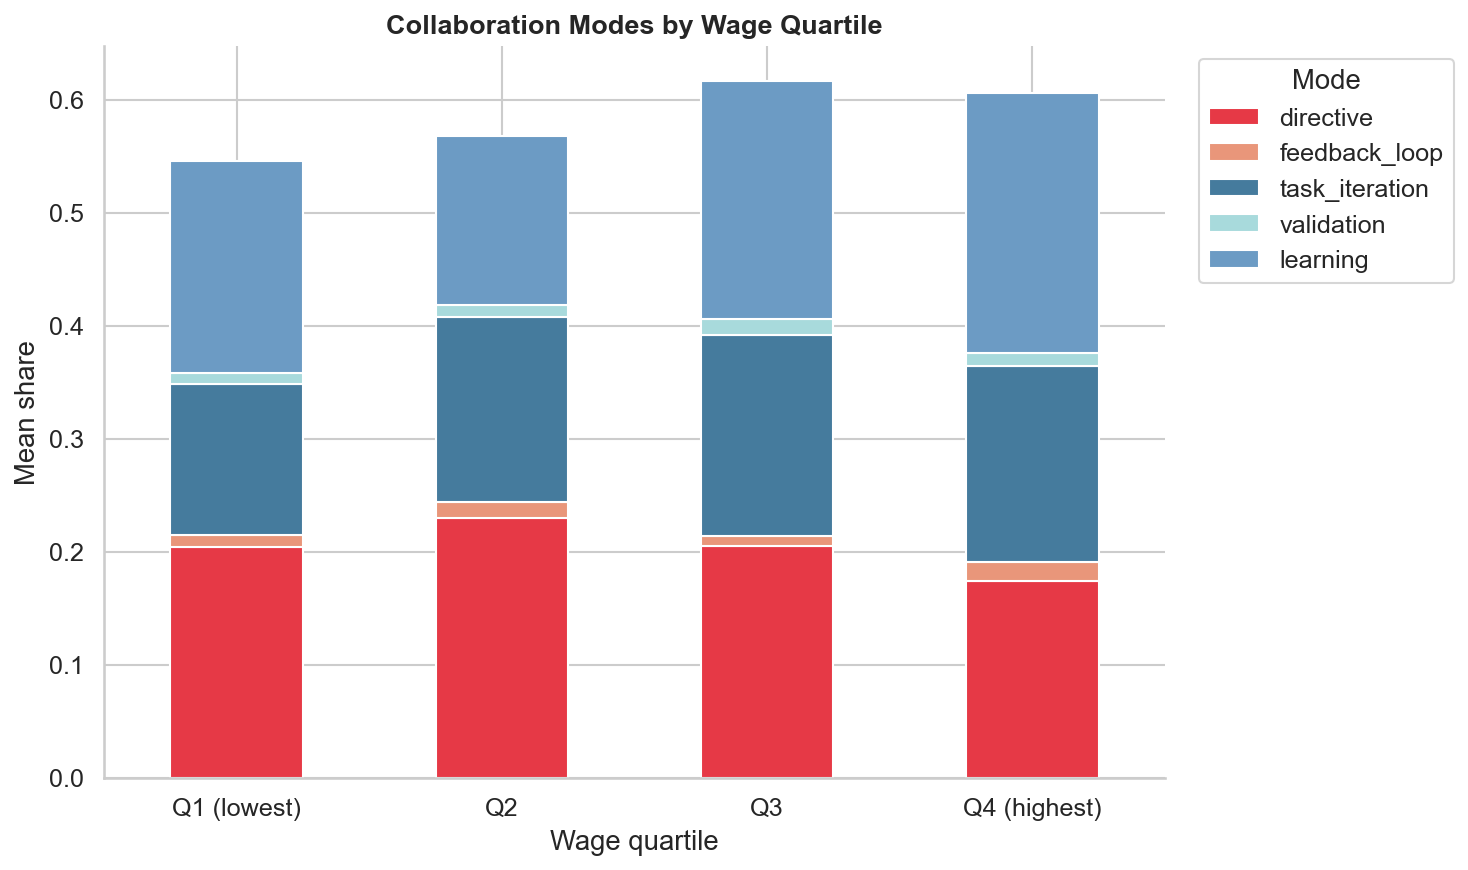

In [7]:
f2 = features.dropna(subset=['mediansalary']).copy()
f2['wage_q'] = pd.qcut(f2['mediansalary'], 4, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])

modes = ['initial_directive', 'initial_feedback_loop', 'initial_task_iteration',
         'initial_validation', 'initial_learning']
labels = ['directive', 'feedback_loop', 'task_iteration', 'validation', 'learning']
available = [m for m in modes if m in f2.columns]
mode_means = f2.groupby('wage_q')[available].mean()
mode_means.columns = [m.replace('initial_', '') for m in available]

fig, ax = plt.subplots(figsize=(10, 6))
mode_means.plot(kind='bar', stacked=True, ax=ax,
                color=[C['auto'], '#E9967A', C['aug'], '#A8DADC', '#6C9BC4'])
ax.set_ylabel('Mean share')
ax.set_xlabel('Wage quartile')
ax.set_title('Collaboration Modes by Wage Quartile', fontsize=13, fontweight='bold')
ax.legend(title='Mode', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
sns.despine()
plt.tight_layout()
plt.savefig('../figures/07_modes_by_wage.png', bbox_inches='tight')
plt.show()

## Feature correlation matrix

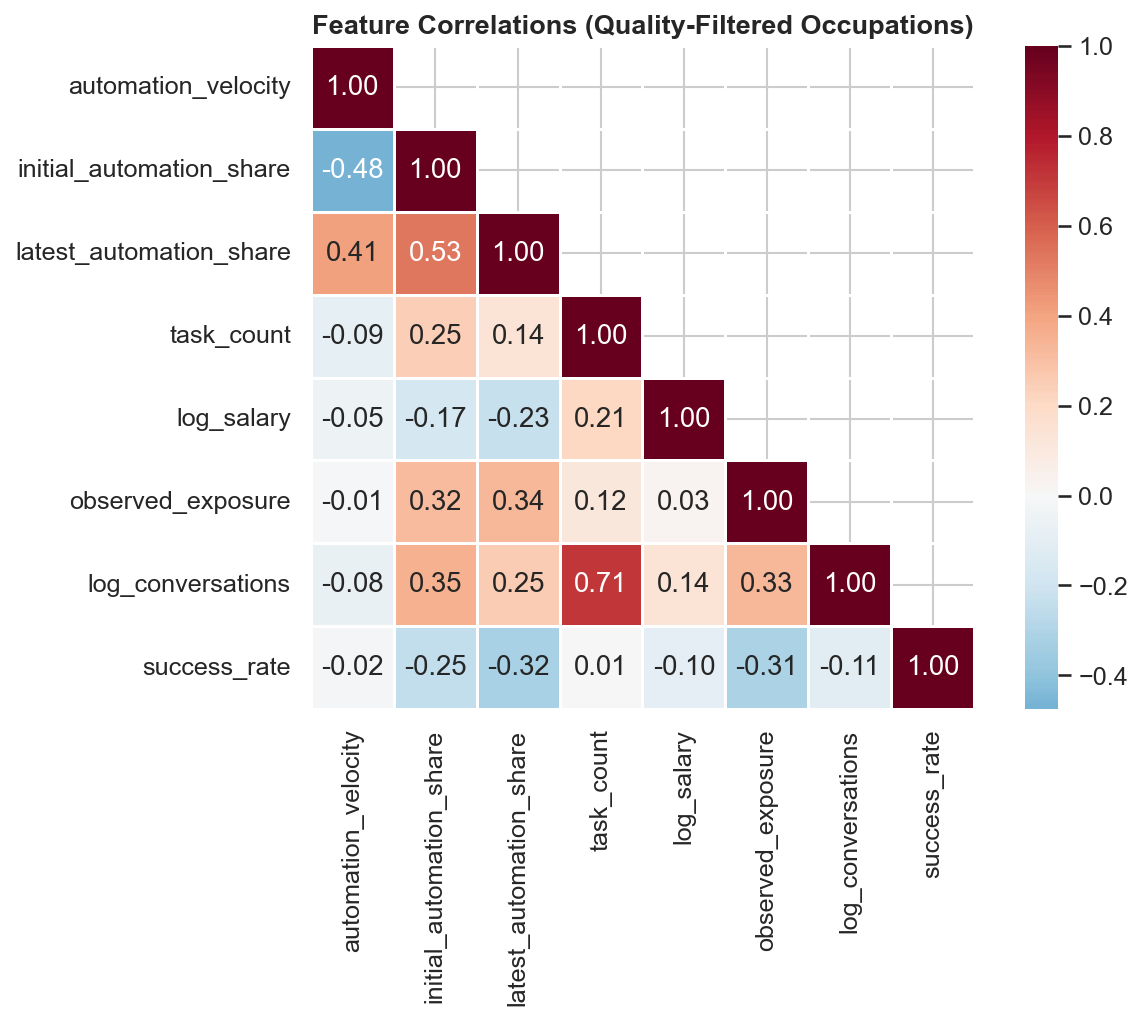


Key correlations with automation_velocity:
  initial_automation_share            -0.48
  task_count                          -0.09
  log_conversations                   -0.08
  log_salary                          -0.05
  success_rate                        -0.02
  observed_exposure                   -0.01
  latest_automation_share             +0.41


In [8]:
corr_cols = [
    'automation_velocity', 'initial_automation_share', 'latest_automation_share',
    'task_count', 'log_salary', 'observed_exposure', 'log_conversations', 'success_rate',
]
corr_cols = [c for c in corr_cols if c in features.columns]
corr_matrix = features[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlations (Quality-Filtered Occupations)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/08_correlation_matrix.png', bbox_inches='tight')
plt.show()

print("\nKey correlations with automation_velocity:")
vel_corr = corr_matrix['automation_velocity'].drop('automation_velocity').sort_values()
for feat, val in vel_corr.items():
    print(f"  {feat:35s} {val:+.2f}")

---

**Key findings:**
1. **Mean reversion dominates** — initial_automation_share correlates *negatively* with velocity (r ~ -0.5)
2. **The frontier is jagged** — wage explains almost none of the variance in automation share
3. **Office/Admin and Food Preparation** have the highest automation shares among groups with enough data
4. **Computer/Math** occupations have the highest conversation volumes but moderate automation shares

**Next:** [03_modeling.ipynb](03_modeling.ipynb)